#Project 6: Dog vs. Cat Image Classification

## Problem Definition


The goal of this project is to build a **Convolutional Neural Network (CNN)** capable of classifying images as either dogs or cats. **Deep learning models** are particularly effective for image recognition because they automatically learn important visual features from raw pixel data. This project demonstrates the complete deep learning workflow, including loading image data, preprocessing, building a CNN, training the model, evaluating its performance, and using it to **classify** a new unseen image.



## Data Collection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

###Enable GPU runtime processing



In [2]:
# tf.config.list_physical_devices('GPU')

In [3]:
#Load images
images_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'
print(images_url)

#Load image pickle
image_array = pd.read_pickle(images_url)
print(type(image_array))

#Load target
target_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'
print(target_url)

#Load target pickle
target = pd.read_pickle(target_url)
target = np.array(target)
print(type(target))

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle
<class 'numpy.ndarray'>
https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle
<class 'numpy.ndarray'>


In [4]:
#Second pass using 500 images
image_array = image_array[:500]
target = target[:500]

## Data Cleaning


In [5]:
#Scale pixel values
image_array = image_array / 255.0

## Exploratory Data Analysis (EDA)


In [6]:
#Check shapes to ensure X is 4D
print(image_array.shape)
print(target.shape)

(500, 100, 100, 1)
(500,)


###Plot Images

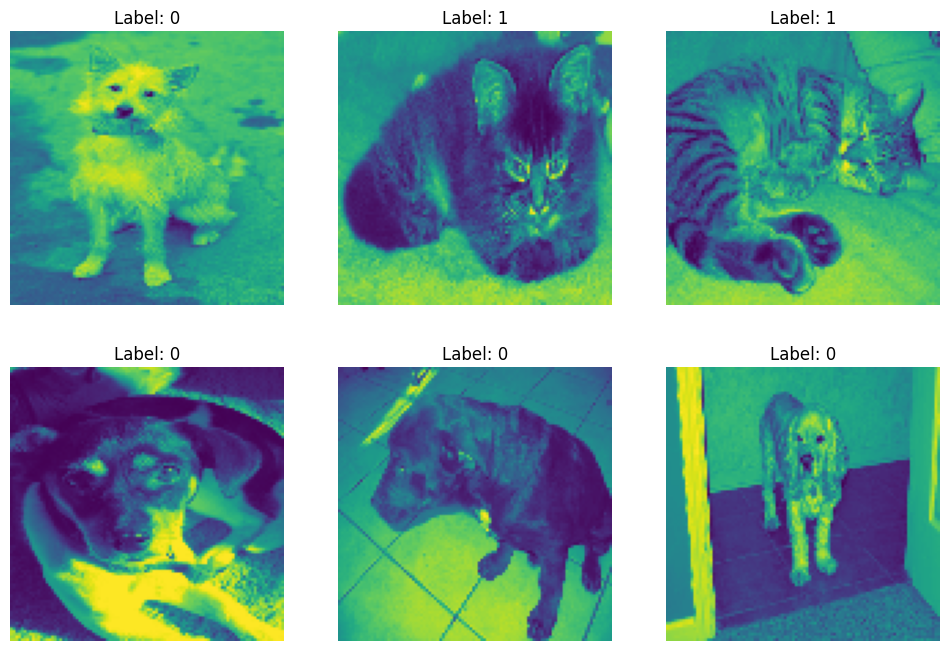

In [7]:
plt.figure(figsize=(12,8))

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(image_array[i])
  plt.title(f'Label: {target[i]}') #Look at y values
  plt.axis('off')

plt.show()

###Plot Random Images

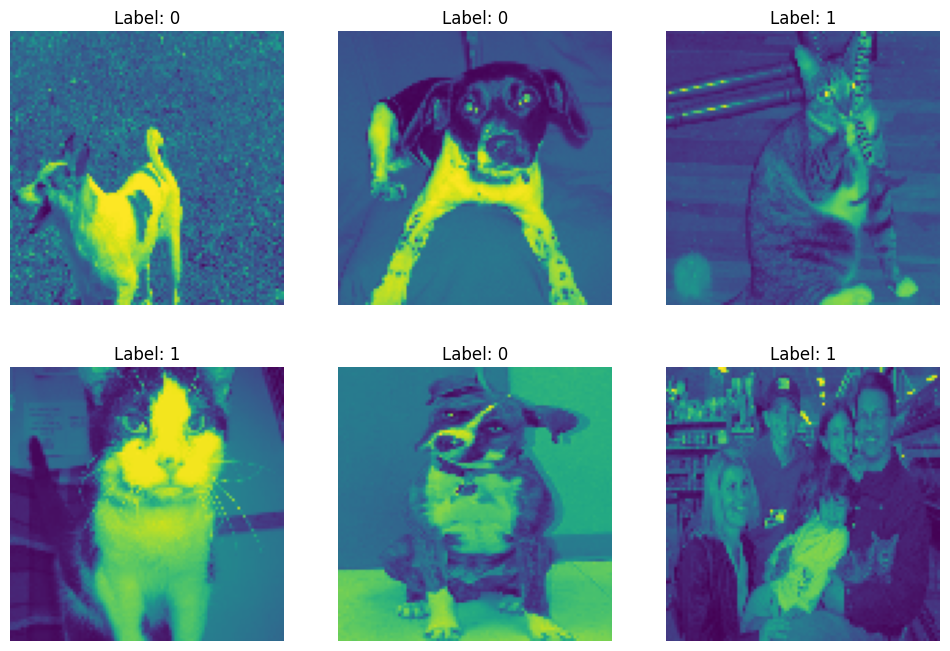

In [8]:
indices = np.random.choice(len(image_array), 6, replace=False)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
  plt.subplot(2,3,i+1)
  plt.imshow(image_array[idx])
  plt.title(f'Label: {target[idx]}')
  plt.axis('off')

plt.show()

## Data Processing


###Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    image_array,
    target,
    test_size=0.20,
    random_state=42
)

###Build Convolutional Neural Networks (CNN)

In [10]:
#Sequential layers
model = Sequential()

#Define input layer
model.add(Input(shape=X_train.shape[1:]))

#First Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

#Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

#Flatten
model.add(Flatten())

#Hidden layer
model.add(Dense(64, activation='relu'))

#Output layer
model.add(Dense(1, activation='sigmoid'))

###Model Summary

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

###Compile and Fit Model

In [12]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Fit model
model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5917 - loss: 0.8058 - val_accuracy: 0.5250 - val_loss: 0.6949
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 801ms/step - accuracy: 0.5389 - loss: 0.6887 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 911ms/step - accuracy: 0.5444 - loss: 0.6899 - val_accuracy: 0.5250 - val_loss: 0.6912
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 874ms/step - accuracy: 0.5389 - loss: 0.6845 - val_accuracy: 0.5250 - val_loss: 0.6935
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 872ms/step - accuracy: 0.5611 - loss: 0.6764 - val_accuracy: 0.5250 - val_loss: 0.6995
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 958ms/step - accuracy: 0.5611 - loss: 0.6934 - val_accuracy: 0.5250 - val_loss: 0.6888
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6028 - loss: 0.6625 - val_accuracy: 0.5250 - val_loss: 0.6928
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6250 - loss: 0.6250 - val_accuracy: 0.4

###Evaluate Model

In [13]:
#Evaluate model using testing set
loss, accuracy = model.evaluate(X_test, y_test)
print()

print('Loss:', loss)
print('Accuracy:', accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5900 - loss: 0.6895

Loss: 0.6894772052764893
Accuracy: 0.5899999737739563


###Plot Distribution of Probabilities

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step



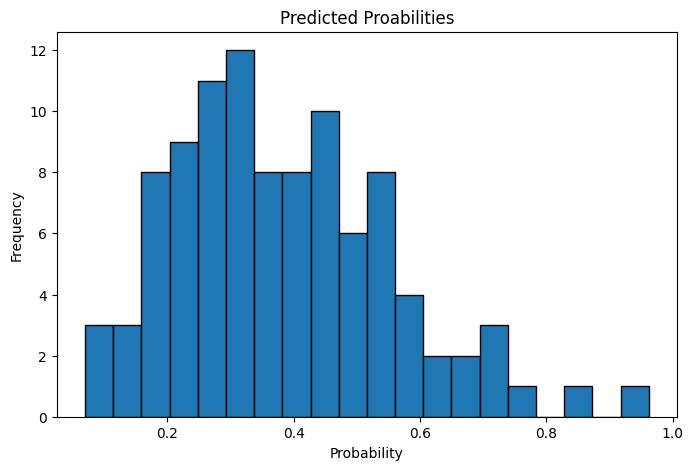

In [14]:
#Predict probabilities
probabilities = model.predict(X_test)
print()

#Plot
plt.figure(figsize=(8,5))

plt.hist(probabilities, bins=20, edgecolor='black')

plt.title('Predicted Proabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

plt.show()

###Create Function to Read New Image

In [15]:
def prepare_image(filepath):

  #Load image
  img = image.load_img(
      filepath,
      target_size=(100, 100),
      color_mode='grayscale'
  )

  #Convert to 3D np array
  img = image.img_to_array(img)

  #Scale pixel values
  img = img / 255.0

  #Convert to 4D array
  img = np.reshape(img, (
    1,   #Batch size of images passing in
    100, #Image height in pixels
    100, #Image width in pixels
    1    #Grayscale
  ))

  return img

###Use Function to Read dog.jpg Image



In [16]:
image_url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg'

#Download the image locally
local_path = tf.keras.utils.get_file('dog.jpg', image_url)

#Run function to create test_image
test_image = prepare_image(local_path)

60603/60603 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


###Use CNN to predict Dog or Cat

In [18]:
#Predict new image
prediction = model.predict(test_image)
print()

#Display prediction
if prediction [0][0] > 0.5:
  print('Cat')
else:
  print('Dog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step

Dog


## Communication of Results


- Compiled CNN
- Cleaned/Organized Notebook
- Split into training and test sets
- Corrected prediction
  - Dog > 0.5
  - Cat < 0.5

## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.